We will generate some visualizations about our data here.

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/data_with_author_and_awards.csv',
    dtype = {
        'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
        'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
        'title_id' : 'Int64'
    },
)
data = data[data.release_year >= 1971]

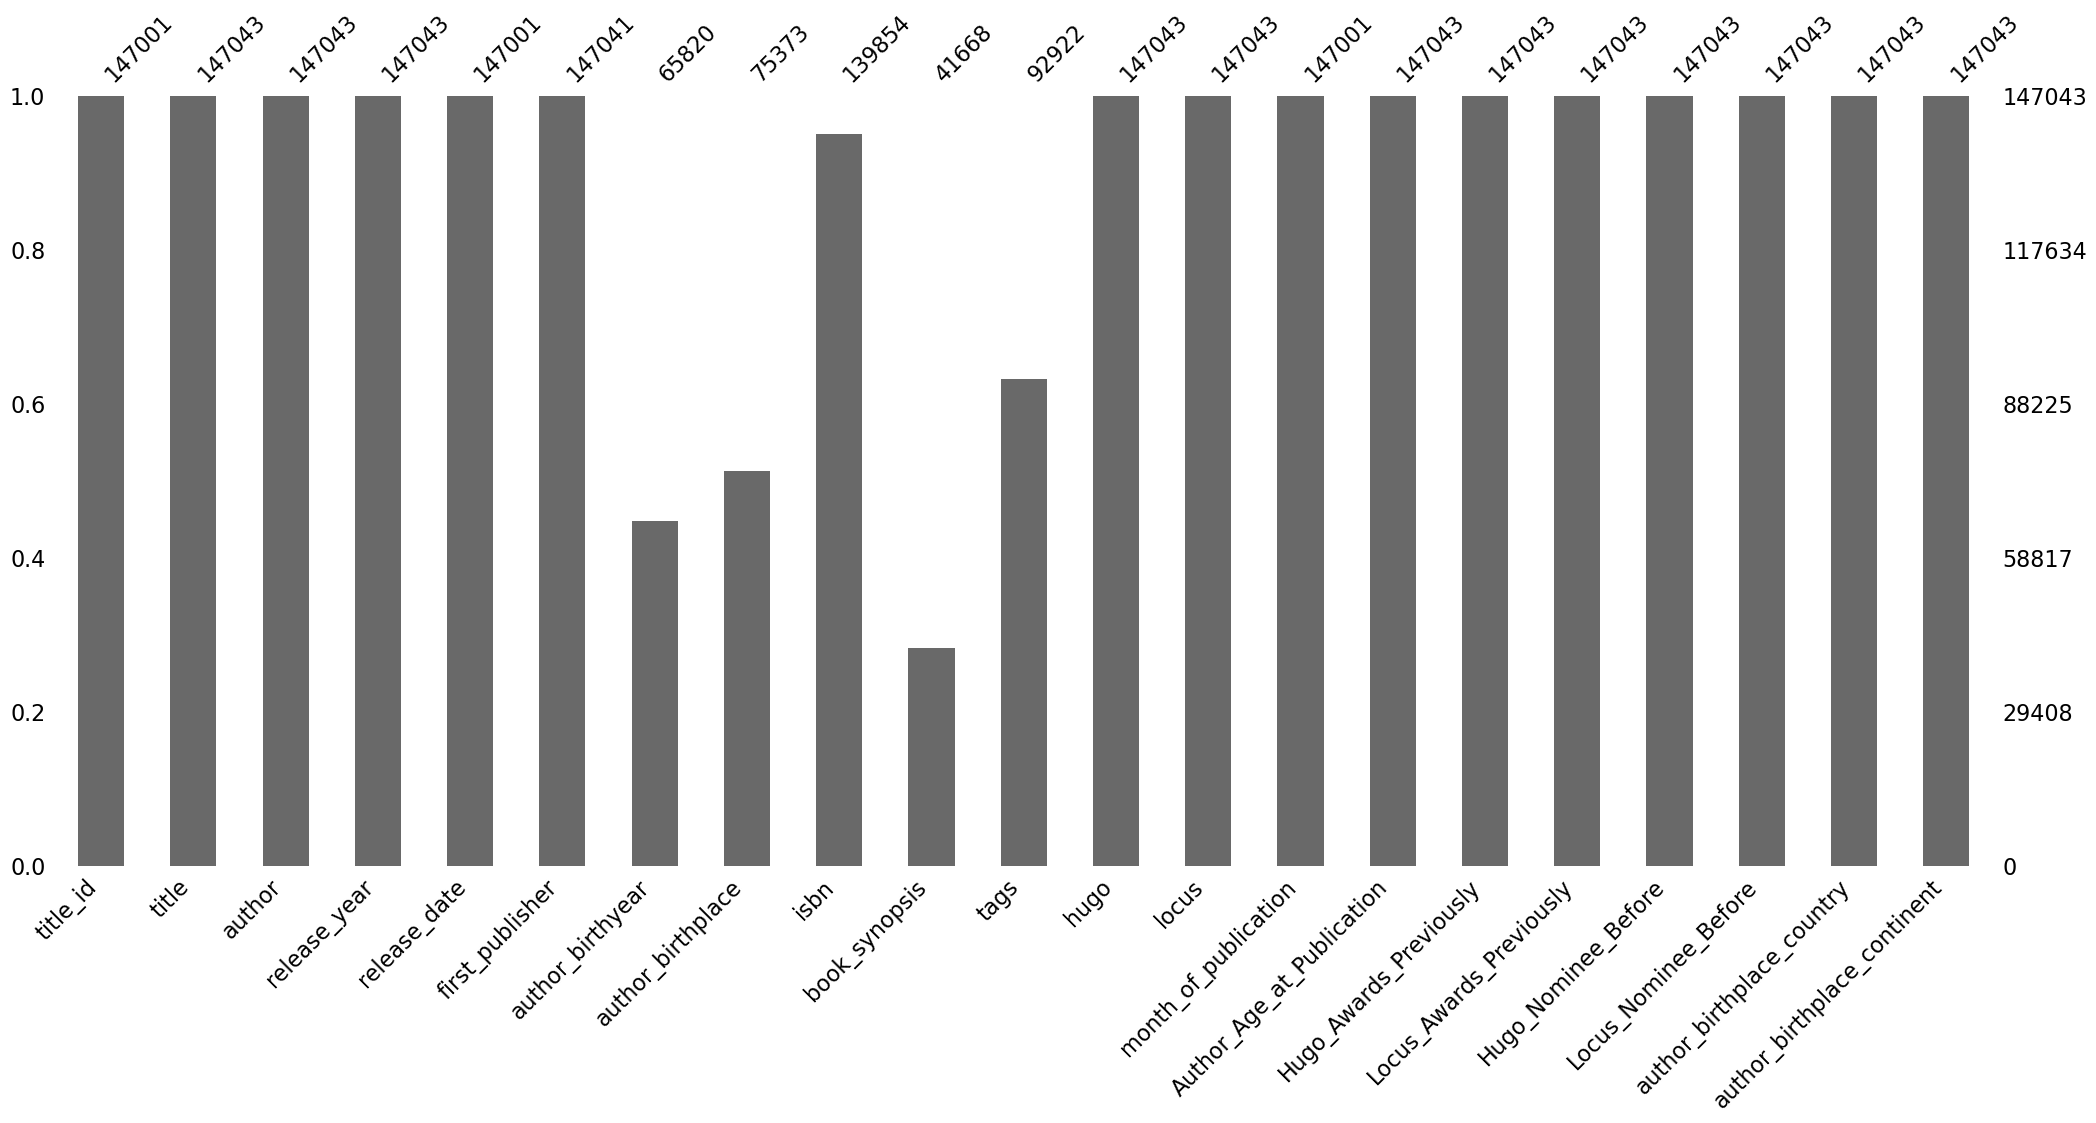

In [3]:
msno.bar(data)
plt.show()

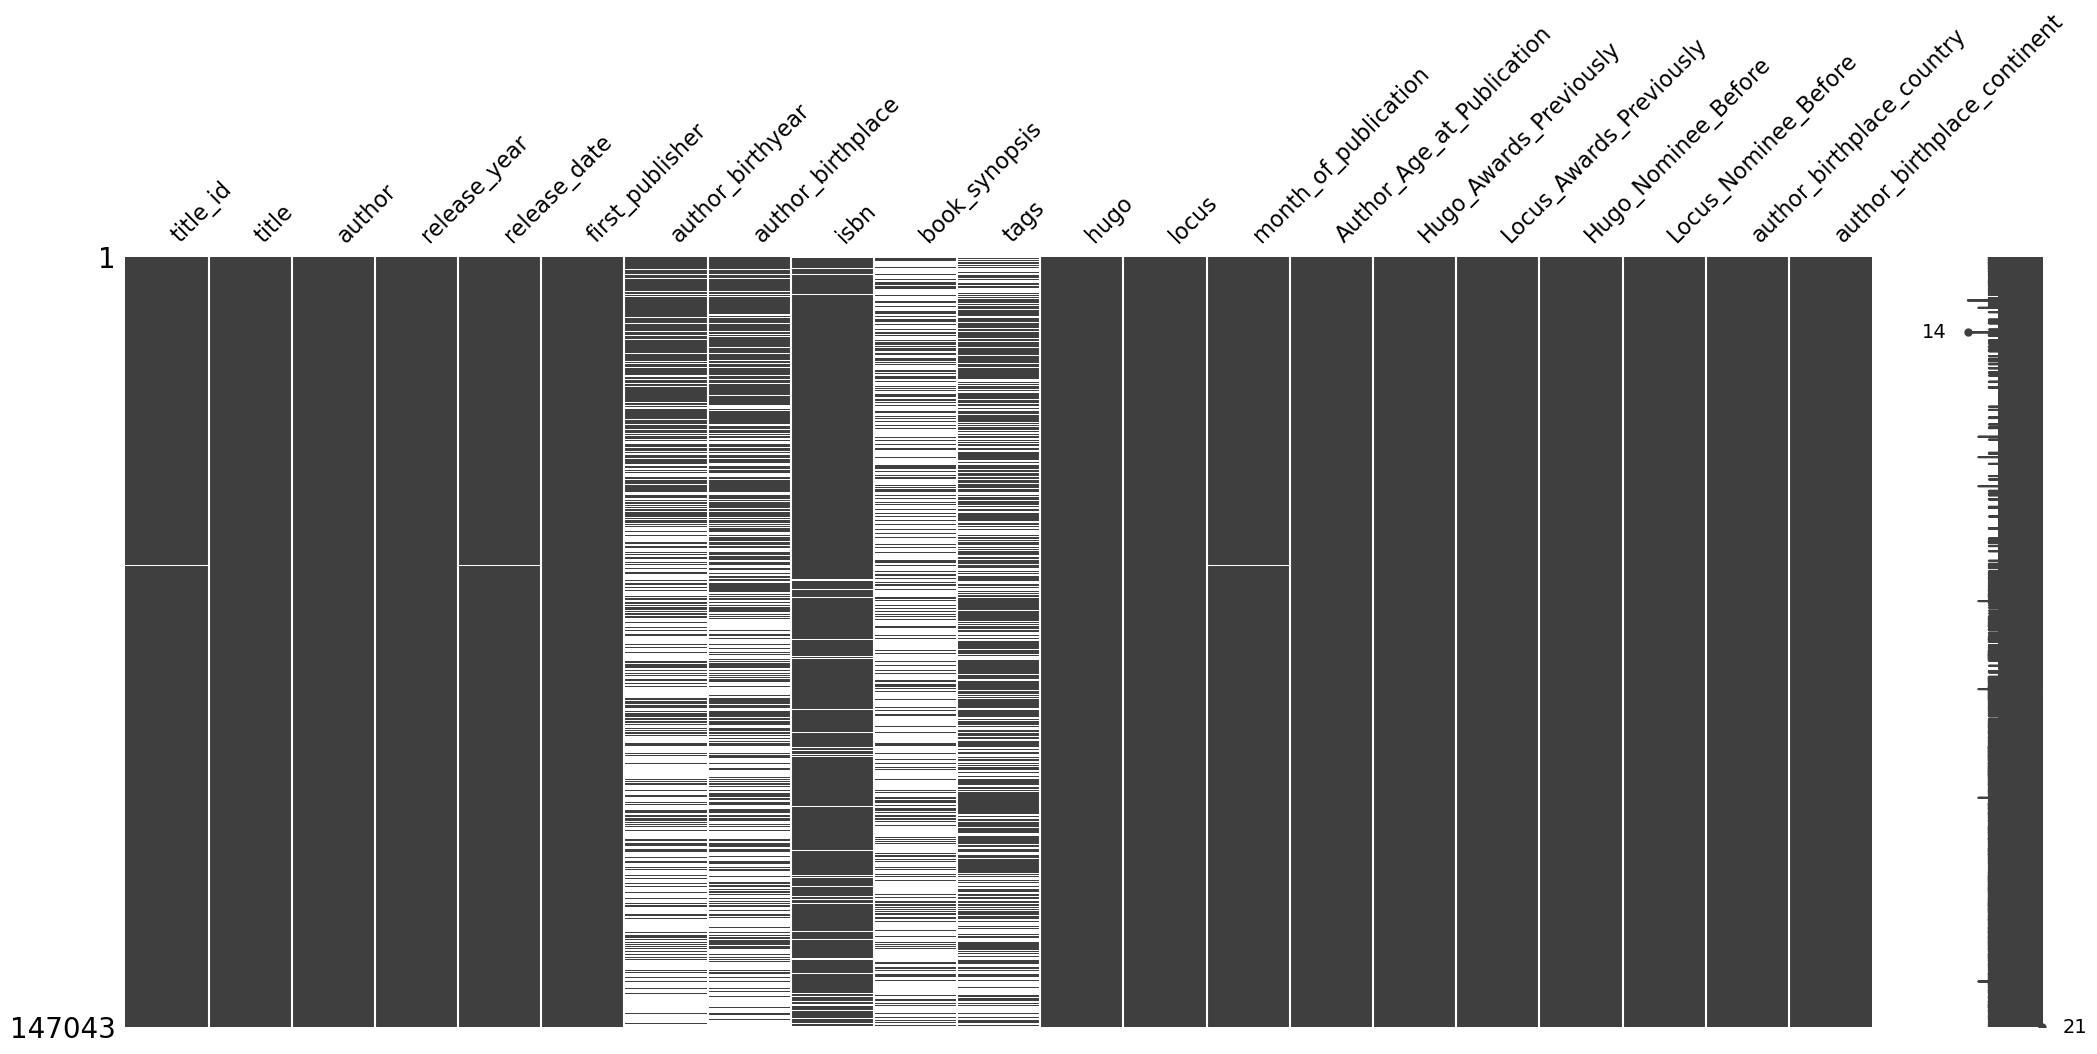

In [4]:
msno.matrix(data)
plt.show()

In [5]:
books_per_year = data.groupby('release_year')['release_year'].value_counts()

In [6]:
books_per_year.tail(15)

release_year
2011    5451
2012    5295
2013    5846
2014    6307
2015    6926
2016    7396
2017    7739
2018    7913
2019    7832
2020    7497
2021    6628
2022    5751
2023    5311
2024    4911
2025    4031
Name: count, dtype: int64

In [11]:
import seaborn as sns 
sns.set_theme(style="whitegrid", font="sans-serif") 
sns.set_palette('BuPu')

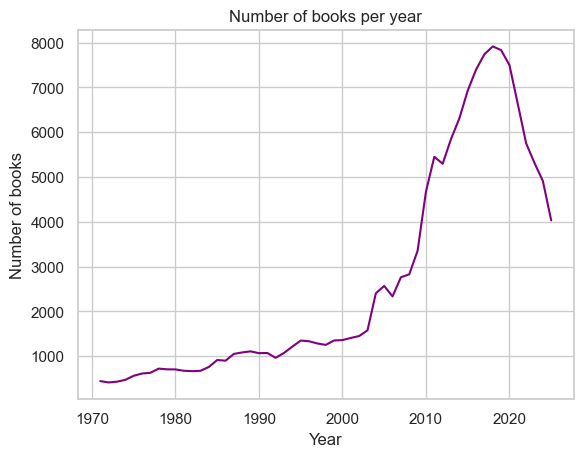

In [13]:
plt.plot(books_per_year, color='purple')
plt.ylabel('Number of books')
plt.xlabel('Year')
plt.title('Number of books per year')
plt.show()

In [14]:
data['target'] = data.locus | data.hugo

nominees_per_year = data[data.target].groupby('release_year')['release_year'].value_counts()

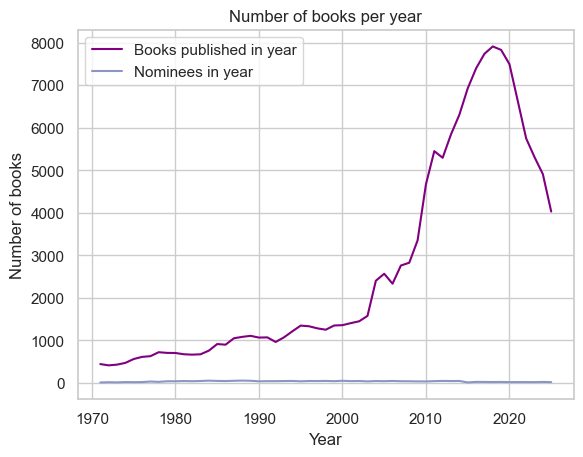

In [16]:
plt.plot(books_per_year, label='Books published in year', color="purple")
plt.plot(nominees_per_year, label='Nominees in year', color='#8c96c6')
plt.ylabel('Number of books')
plt.xlabel('Year')
plt.title('Number of books per year')
plt.legend()
plt.show()

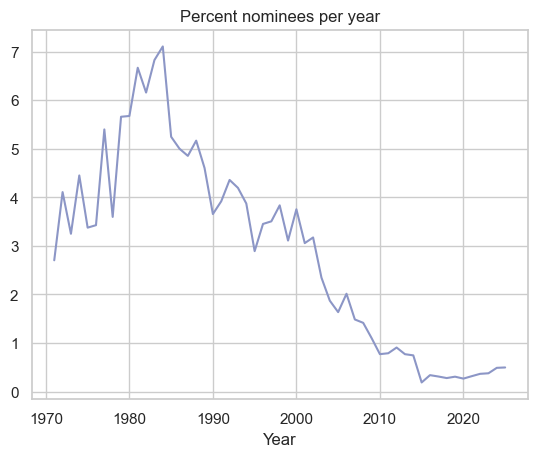

In [19]:
plt.plot((nominees_per_year / books_per_year) * 100, label='Percent nominees', color='#8c96c6')
plt.xlabel('Year')
plt.title('Percent nominees per year')
plt.show()